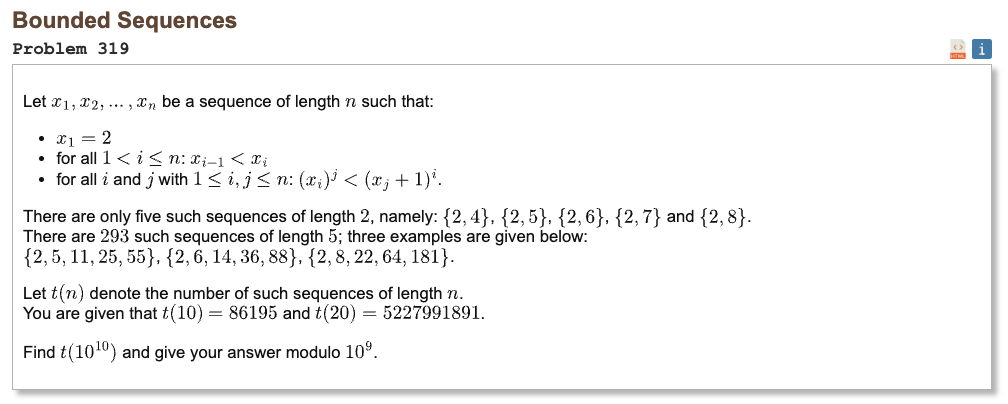

## Initial approach

* turn each valid sequence into one interval choice for a hidden base value
* the sequence changes only when one of the powers crosses an integer boundary
* count those boundary points instead of building the sequences directly
* use mobius inversion to avoid double counting repeated power patterns
* use a fast prefix sum of the mobius values for the huge input size
* use modular arithmetic because only the final remainder is needed
* test the code with the given small values before printing the target result

In [1]:
MOD = 10 ** 9

def integer_cuberoot_floor(n):
    x = int(round(n ** (1.0 / 3.0)))

    while (x + 1) ** 3 <= n:
        x += 1

    while x ** 3 > n:
        x -= 1

    return x

def linear_sieve_mobius_prefix(limit):
    is_comp = bytearray(limit + 1)
    mu = [0] * (limit + 1)
    pref = [0] * (limit + 1)
    primes = []
    mu[1] = 1

    for i in range(2, limit + 1):
        if not is_comp[i]:
            primes.append(i)
            mu[i] = -1

        for p in primes:
            ip = i * p

            if ip > limit:
                break

            is_comp[ip] = 1

            if i % p == 0:
                mu[ip] = 0
                break

            mu[ip] = -mu[i]

    total = 0

    for i in range(1, limit + 1):
        total += mu[i]
        pref[i] = total

    return pref

class Mertens:
    def __init__(self, max_n):
        c = integer_cuberoot_floor(max_n)
        self.limit = c * c
        self.pref = linear_sieve_mobius_prefix(self.limit)
        self.cache = {}

    def get(self, n):
        if n <= 0:
            return 0

        if n <= self.limit:
            return self.pref[n]

        if n in self.cache:
            return self.cache[n]

        result = 1
        i = 2

        while i <= n:
            q = n // i
            j = n // q
            result -= (j - i + 1) * self.get(q)
            i = j + 1

        self.cache[n] = result
        return result

def G(m, mod):
    if m <= 0:
        return 0

    mod2 = 2 * mod

    sum3 = ((pow(3, m + 1, mod2) - 3) % mod2) // 2
    sum2 = (pow(2, m + 1, mod) - 2) % mod

    return (sum3 - sum2 - m) % mod

def t(n, mod=MOD):
    mertens = Mertens(n)
    total = 0
    i = 1

    while i <= n:
        q = n // i
        j = n // q
        mu_sum = mertens.get(j) - mertens.get(i - 1)
        total = (total + (mu_sum % mod) * G(q, mod)) % mod
        i = j + 1

    return (total + 1) % mod

def t_small(n):
    mu = [0] * (n + 1)
    is_comp = [False] * (n + 1)
    primes = []
    mu[1] = 1

    for i in range(2, n + 1):
        if not is_comp[i]:
            primes.append(i)
            mu[i] = -1

        for p in primes:
            ip = i * p

            if ip > n:
                break

            is_comp[ip] = True

            if i % p == 0:
                mu[ip] = 0
                break

            mu[ip] = -mu[i]

    total = 0

    for k in range(1, n + 1):
        current = 0

        for d in range(1, k + 1):
            if k % d == 0:
                current += mu[d] * (3 ** (k // d) - 2 ** (k // d) - 1)

        total += current

    return total + 1

assert t_small(2) == 5
assert t_small(5) == 293
assert t_small(10) == 86195
assert t_small(20) == 5227991891

In [2]:
%%time
result = t(10 ** 10)
print("Result:", result)

Result: 268457129
CPU times: user 3.23 s, sys: 44.4 ms, total: 3.28 s
Wall time: 3.29 s
